<a href="https://colab.research.google.com/github/bernardenh-dabs/coffee-sales-analysis/blob/main/mental_health_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("/content/sample_data/mental_health_productivity_2026.csv")

df.head()

,Employee_ID,Age,Gender,Country,Industry,Work_Mode,Work_Hours_Per_Week,Stress_Level,Sleep_Hours,Productivity_Score,Physical_Activity_Hours,Mental_Health_Support_Access,Burnout_Risk
0,EMP_0001,50,Male,USA,Manufacturing,Remote,40,9,7.377341,89,6.564715,Yes,High
1,EMP_0002,36,Male,UK,Finance,Remote,35,1,6.186889,61,0.184572,Yes,Low
2,EMP_0003,29,Male,Brazil,Finance,Remote,52,4,7.474883,47,8.318881,No,Low
3,EMP_0004,42,Female,UK,Manufacturing,Remote,56,10,7.169386,49,1.746996,No,High
4,EMP_0005,40,Male,Germany,Tech,On-site,35,2,9.518479,53,5.154975,Yes,Low


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Employee_ID                   1500 non-null   object 
 1   Age                           1500 non-null   int64  
 2   Gender                        1500 non-null   object 
 3   Country                       1500 non-null   object 
 4   Industry                      1500 non-null   object 
 5   Work_Mode                     1500 non-null   object 
 6   Work_Hours_Per_Week           1500 non-null   int64  
 7   Stress_Level                  1500 non-null   int64  
 8   Sleep_Hours                   1500 non-null   float64
 9   Productivity_Score            1500 non-null   int64  
 10  Physical_Activity_Hours       1500 non-null   float64
 11  Mental_Health_Support_Access  1500 non-null   object 
 12  Burnout_Risk                  1500 non-null   object 
dtypes: 

,Age,Work_Hours_Per_Week,Stress_Level,Sleep_Hours,Productivity_Score,Physical_Activity_Hours
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,41.002667,46.980000,6.244667,6.972800,69.837333,5.005239
std,11.062681,10.042252,2.987544,1.215902,17.397260,2.898687
min,22.000000,30.000000,1.000000,4.000000,40.000000,0.010870
25%,31.000000,38.000000,4.000000,6.137665,55.000000,2.525866
50%,42.000000,47.000000,7.000000,6.981871,70.000000,5.022898
75%,50.000000,55.250000,9.000000,7.818334,84.000000,7.525873
max,59.000000,64.000000,10.000000,10.000000,100.000000,9.996356


In [3]:
#Check Missing Values
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Country,0
Industry,0
Work_Mode,0
Work_Hours_Per_Week,0
Stress_Level,0
Sleep_Hours,0
Productivity_Score,0


In [4]:
#Handle Missing Values
df.fillna(df.median(numeric_only=True), inplace=True)


In [5]:
#Remove Duplicates
df.drop_duplicates(inplace=True)

In [6]:
#Standardize Column Names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [7]:
#Standardize Text Values for relevant categorical columns
for col in ['gender', 'country', 'industry', 'work_mode', 'mental_health_support_access', 'burnout_risk']:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [8]:
df['stress_level'] = df['stress_level'].replace({
    'high ': 'high',
    'High': 'high',
    'LOW': 'low',
    'medium ': 'medium'
})

In [9]:
df['sleep_hours'] = pd.to_numeric(df['sleep_hours'], errors='coerce')


In [10]:
df['sleep_hours'] = df['sleep_hours'].astype(str).str.replace('hrs', '')
df['sleep_hours'] = pd.to_numeric(df['sleep_hours'], errors='coerce')

In [11]:
df['stress_level'] = df['stress_level'].replace({
    'very high': 'high',
    'very low': 'low'
})

In [12]:
df.nunique()
df.head()

,employee_id,age,gender,country,industry,work_mode,work_hours_per_week,stress_level,sleep_hours,productivity_score,physical_activity_hours,mental_health_support_access,burnout_risk
0,EMP_0001,50,male,usa,manufacturing,remote,40,9,7.377341,89,6.564715,yes,high
1,EMP_0002,36,male,uk,finance,remote,35,1,6.186889,61,0.184572,yes,low
2,EMP_0003,29,male,brazil,finance,remote,52,4,7.474883,47,8.318881,no,low
3,EMP_0004,42,female,uk,manufacturing,remote,56,10,7.169386,49,1.746996,no,high
4,EMP_0005,40,male,germany,tech,on-site,35,2,9.518479,53,5.154975,yes,low


In [13]:
df['country'].unique()

array(['usa', 'uk', 'brazil', 'germany', 'canada', 'singapore',
       'australia', 'japan', 'france', 'india'], dtype=object)

In [14]:
df.nunique()
df.head()

,employee_id,age,gender,country,industry,work_mode,work_hours_per_week,stress_level,sleep_hours,productivity_score,physical_activity_hours,mental_health_support_access,burnout_risk
0,EMP_0001,50,male,usa,manufacturing,remote,40,9,7.377341,89,6.564715,yes,high
1,EMP_0002,36,male,uk,finance,remote,35,1,6.186889,61,0.184572,yes,low
2,EMP_0003,29,male,brazil,finance,remote,52,4,7.474883,47,8.318881,no,low
3,EMP_0004,42,female,uk,manufacturing,remote,56,10,7.169386,49,1.746996,no,high
4,EMP_0005,40,male,germany,tech,on-site,35,2,9.518479,53,5.154975,yes,low


In [15]:
df['country'] = df['country'].str.strip().str.lower()

In [16]:
country_map = {
    'usa': 'United States',
    'us': 'United States',
    'united states': 'United States',

    'uk': 'United Kingdom',
    'britain': 'United Kingdom',
    'england': 'United Kingdom',
    'united kingdom': 'United Kingdom',

    'ghana': 'Ghana',

    'germany': 'Germany',

    'spain': 'Spain'
}

In [17]:
df['country'] = df['country'].replace(country_map)

In [18]:
df.head()

,employee_id,age,gender,country,industry,work_mode,work_hours_per_week,stress_level,sleep_hours,productivity_score,physical_activity_hours,mental_health_support_access,burnout_risk
0,EMP_0001,50,male,United States,manufacturing,remote,40,9,7.377341,89,6.564715,yes,high
1,EMP_0002,36,male,United Kingdom,finance,remote,35,1,6.186889,61,0.184572,yes,low
2,EMP_0003,29,male,brazil,finance,remote,52,4,7.474883,47,8.318881,no,low
3,EMP_0004,42,female,United Kingdom,manufacturing,remote,56,10,7.169386,49,1.746996,no,high
4,EMP_0005,40,male,Germany,tech,on-site,35,2,9.518479,53,5.154975,yes,low


In [19]:
df['country'].unique()

array(['United States', 'United Kingdom', 'brazil', 'Germany', 'canada',
       'singapore', 'australia', 'japan', 'france', 'india'], dtype=object)

In [20]:
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 56.0 MB/s eta 0:00:00


In [21]:
import pycountry

def standardize_country(name):
    try:
        return pycountry.countries.lookup(name).name
    except:
        return name

df['country'] = df['country'].apply(standardize_country)

In [22]:
df['country'].value_counts()

,count
country,
United States,169
Canada,164
United Kingdom,158
Brazil,148
Japan,148
Germany,146
France,146
Singapore,143
India,141


In [23]:
df['industry'].unique()

array(['manufacturing', 'finance', 'tech', 'education', 'healthcare',
       'retail'], dtype=object)

In [24]:
df['industry'] = df['industry'].str.strip().str.lower()

In [25]:
industry_map = {
    # Technology
    'tech': 'Technology',
    'technology': 'Technology',
    'it': 'Technology',
    'it services': 'Technology',
    'software': 'Technology',

    # Healthcare
    'healthcare': 'Healthcare',
    'health care': 'Healthcare',
    'medical': 'Healthcare',
    'hospital': 'Healthcare',

    # Finance
    'finance': 'Finance',
    'banking': 'Finance',
    'fintech': 'Finance',

    # Education
    'education': 'Education',
    'school': 'Education',
    'university': 'Education',

    # Manufacturing
    'manufacturing': 'Manufacturing',
    'factory': 'Manufacturing',

    # Retail
    'retail': 'Retail',
    'ecommerce': 'Retail',
    'e-commerce': 'Retail'
}

In [26]:
df['industry'] = df['industry'].replace(industry_map)

In [27]:
df['industry'].value_counts()

,count
industry,
Education,264
Retail,260
Finance,252
Manufacturing,252
Healthcare,241
Technology,231


In [28]:
df[~df['industry'].isin(industry_map.values())]['industry'].unique()

array([], dtype=object)

In [29]:
top_industries = df['industry'].value_counts().nlargest(5).index

df['industry'] = df['industry'].apply(lambda x: x if x in top_industries else 'Other')

In [30]:
stress_prod = df.groupby('stress_level')['productivity_score'].mean().sort_values()
print(stress_prod)

stress_level
2     67.561798
4     68.162963
6     68.693431
10    68.890675
9     69.431507
3     69.441176
7     71.020833
1     71.080882
8     71.715232
5     72.228188
Name: productivity_score, dtype: float64


In [31]:
sleep_prod = df.groupby('sleep_hours')['productivity_score'].mean()
print(sleep_prod)

sleep_hours
4.000000     51.700000
4.025634     59.000000
4.128870     50.000000
4.170770     82.000000
4.208366     60.000000
               ...    
9.911756     85.000000
9.926628     77.000000
9.953195     68.000000
9.967919     60.000000
10.000000    80.142857
Name: productivity_score, Length: 1485, dtype: float64


In [32]:
work_prod = df.groupby('work_hours_per_week')['productivity_score'].mean()
print(work_prod)

work_hours_per_week
30    70.024390
31    69.903846
32    69.589744
33    79.290323
34    72.933333
35    72.644444
36    62.878049
37    74.475000
38    71.555556
39    69.822222
40    74.000000
41    70.422222
42    73.978261
43    67.657143
44    67.690476
45    67.021277
46    68.864865
47    71.811321
48    66.000000
49    75.909091
50    62.487179
51    73.121951
52    74.266667
53    64.600000
54    67.688889
55    71.509804
56    60.944444
57    71.522727
58    69.122449
59    65.400000
60    73.418605
61    66.454545
62    67.104167
63    70.069767
64    66.871795
Name: productivity_score, dtype: float64


In [33]:
industry_prod = df.groupby('industry')['productivity_score'].mean().sort_values(ascending=False)
print(industry_prod)

industry
Other            70.467532
Manufacturing    70.345238
Retail           70.126923
Healthcare       69.663900
Finance          69.492063
Education        69.003788
Name: productivity_score, dtype: float64


In [34]:
df.corr(numeric_only=True)

,age,work_hours_per_week,stress_level,sleep_hours,productivity_score,physical_activity_hours
age,1.000000,-0.012093,-0.038149,0.013847,0.008273,-0.004207
work_hours_per_week,-0.012093,1.000000,0.512965,-0.035922,-0.064417,0.027188
stress_level,-0.038149,0.512965,1.000000,0.005505,-0.005600,0.000655
sleep_hours,0.013847,-0.035922,0.005505,1.000000,0.269024,0.000210
productivity_score,0.008273,-0.064417,-0.005600,0.269024,1.000000,-0.002225
physical_activity_hours,-0.004207,0.027188,0.000655,0.000210,-0.002225,1.000000


In [35]:
import pandas as pd

# Load data
df = pd.read_csv("/content/sample_data/mental_health_productivity_2026.csv")

# ----------------------------
# 1. Clean column names
# ----------------------------
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# ----------------------------
# 2. Remove duplicates
# ----------------------------
df.drop_duplicates(inplace=True)

# ----------------------------
# 3. Handle missing values
# ----------------------------
df.fillna(df.median(numeric_only=True), inplace=True)

# ----------------------------
# 4. Standardize text columns
# ----------------------------
# df['stress_level'] = df['stress_level'].str.strip().str.lower() # This line caused the error
df['industry'] = df['industry'].str.strip().str.lower()
df['country'] = df['country'].str.strip().str.lower()

# ----------------------------
# 5. Standardize industry
# ----------------------------
industry_map = {
    'tech': 'Technology',
    'it': 'Technology',
    'software': 'Technology',
    'healthcare': 'Healthcare',
    'medical': 'Healthcare',
    'finance': 'Finance',
    'banking': 'Finance',
    'education': 'Education',
    'retail': 'Retail'
}

df['industry'] = df['industry'].replace(industry_map)

# ----------------------------
# 6. Standardize country
# ----------------------------
country_map = {
    'usa': 'United States',
    'us': 'United States',
    'uk': 'United Kingdom',
    'ghana': 'Ghana',
    'germany': 'Germany',
    'spain': 'Spain'
}

df['country'] = df['country'].replace(country_map)

# ----------------------------
# 7. Convert numeric columns
# ----------------------------
df['sleep_hours'] = pd.to_numeric(df['sleep_hours'], errors='coerce')
df['work_hours_per_week'] = pd.to_numeric(df['work_hours_per_week'], errors='coerce') # Corrected column name
df['productivity_score'] = pd.to_numeric(df['productivity_score'], errors='coerce')

# ----------------------------
# 8. Feature Engineering
# ----------------------------
df['productivity_level'] = pd.cut(
    df['productivity_score'],
    bins=[0, 40, 70, 100],
    labels=['Low', 'Medium', 'High']
)

# ----------------------------
# 9. Final check
# ----------------------------
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   employee_id                   1500 non-null   object  
 1   age                           1500 non-null   int64   
 2   gender                        1500 non-null   object  
 3   country                       1500 non-null   object  
 4   industry                      1500 non-null   object  
 5   work_mode                     1500 non-null   object  
 6   work_hours_per_week           1500 non-null   int64   
 7   stress_level                  1500 non-null   int64   
 8   sleep_hours                   1500 non-null   float64 
 9   productivity_score            1500 non-null   int64   
 10  physical_activity_hours       1500 non-null   float64 
 11  mental_health_support_access  1500 non-null   object  
 12  burnout_risk                  1500 non-null   ob

,employee_id,age,gender,country,industry,work_mode,work_hours_per_week,stress_level,sleep_hours,productivity_score,physical_activity_hours,mental_health_support_access,burnout_risk,productivity_level
0,EMP_0001,50,Male,United States,manufacturing,Remote,40,9,7.377341,89,6.564715,Yes,High,High
1,EMP_0002,36,Male,United Kingdom,Finance,Remote,35,1,6.186889,61,0.184572,Yes,Low,Medium
2,EMP_0003,29,Male,brazil,Finance,Remote,52,4,7.474883,47,8.318881,No,Low,Medium
3,EMP_0004,42,Female,United Kingdom,manufacturing,Remote,56,10,7.169386,49,1.746996,No,High,Medium
4,EMP_0005,40,Male,Germany,Technology,On-site,35,2,9.518479,53,5.154975,Yes,Low,Medium


In [36]:
df.to_csv("cleaned_mental_health_productivity.csv", index=False)

In [37]:
from google.colab import files
files.download("cleaned_mental_health_productivity.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
from google.colab import files
files.download("cleaned_mental_health_productivity.csv")

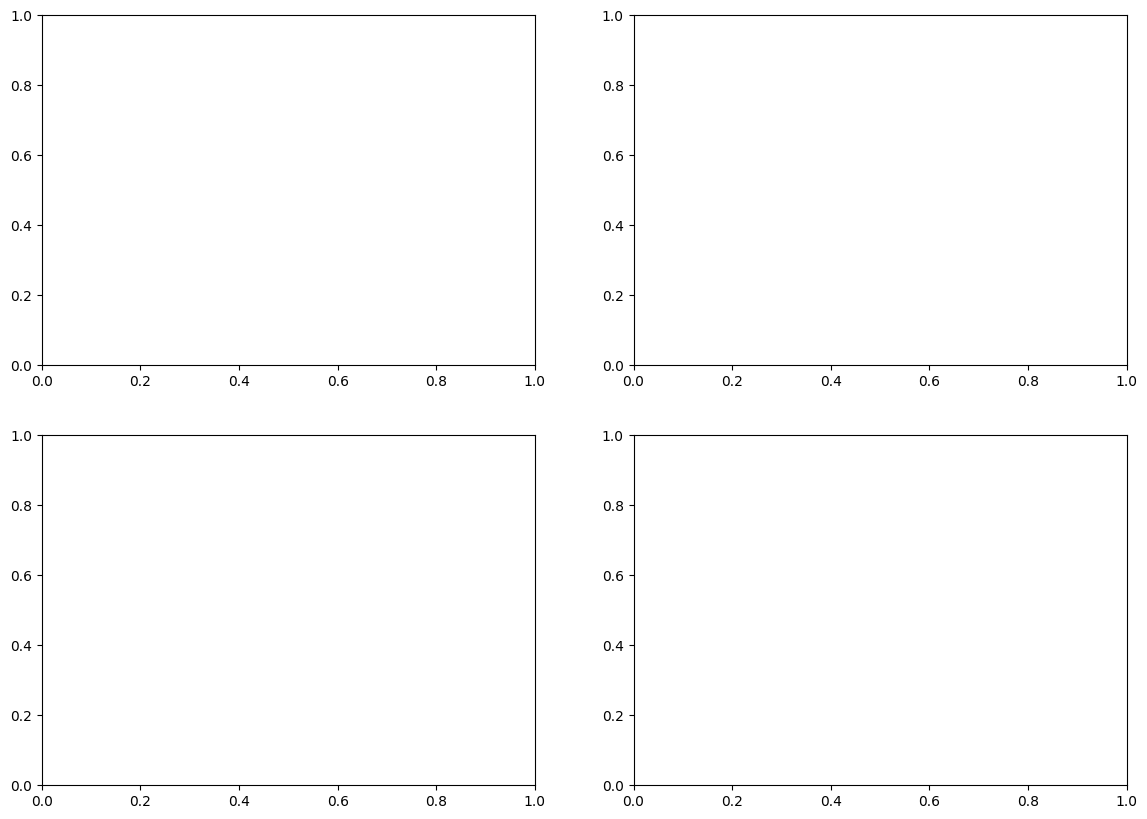

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

In [40]:
df.groupby('stress_level')['productivity_score'].mean().plot(
    ax=axes[0,0], kind='bar'
)
axes[0,0].set_title("Stress vs Productivity")
axes[0,0].set_xlabel("Stress Level")
axes[0,0].set_ylabel("Avg Productivity")

Text(4.444444444444452, 0.5, 'Avg Productivity')

In [41]:
df.groupby('sleep_hours')['productivity_score'].mean().plot(
    ax=axes[0,1], kind='line'
)
axes[0,1].set_title("Sleep vs Productivity")
axes[0,1].set_xlabel("Sleep Hours")
axes[0,1].set_ylabel("Avg Productivity")

Text(596.2626262626262, 0.5, 'Avg Productivity')

In [42]:
df.groupby('work_hours_per_week')['productivity_score'].mean().plot(
    ax=axes[1,0], kind='line'
)
axes[1,0].set_title("Work Hours vs Productivity")
axes[1,0].set_xlabel("Work Hours Per Week")
axes[1,0].set_ylabel("Avg Productivity")

Text(4.444444444444452, 0.5, 'Avg Productivity')

In [43]:
df.groupby('industry')['productivity_score'].mean().plot(
    ax=axes[1,1], kind='bar'
)
axes[1,1].set_title("Productivity by Industry")
axes[1,1].set_xlabel("Industry")
axes[1,1].set_ylabel("Avg Productivity")

Text(596.2626262626262, 0.5, 'Avg Productivity')

In [44]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

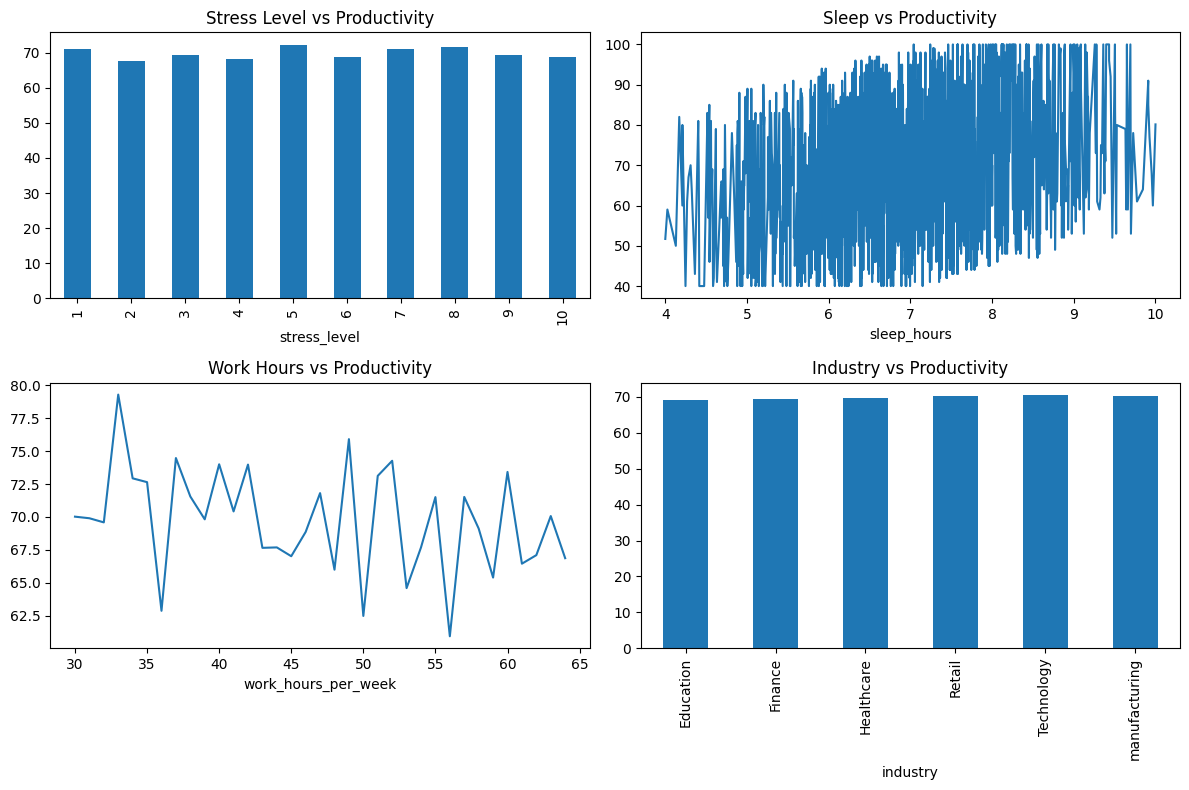

In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Stress vs Productivity
df.groupby('stress_level')['productivity_score'].mean().plot(
    ax=axes[0,0], kind='bar'
)
axes[0,0].set_title("Stress Level vs Productivity")

# Sleep vs Productivity
df.groupby('sleep_hours')['productivity_score'].mean().plot(
    ax=axes[0,1], kind='line'
)
axes[0,1].set_title("Sleep vs Productivity")

# Work Hours vs Productivity
df.groupby('work_hours_per_week')['productivity_score'].mean().plot(
    ax=axes[1,0], kind='line'
)
axes[1,0].set_title("Work Hours vs Productivity")

# Industry vs Productivity
df.groupby('industry')['productivity_score'].mean().plot(
    ax=axes[1,1], kind='bar'
)
axes[1,1].set_title("Industry vs Productivity")

plt.tight_layout()
plt.show()

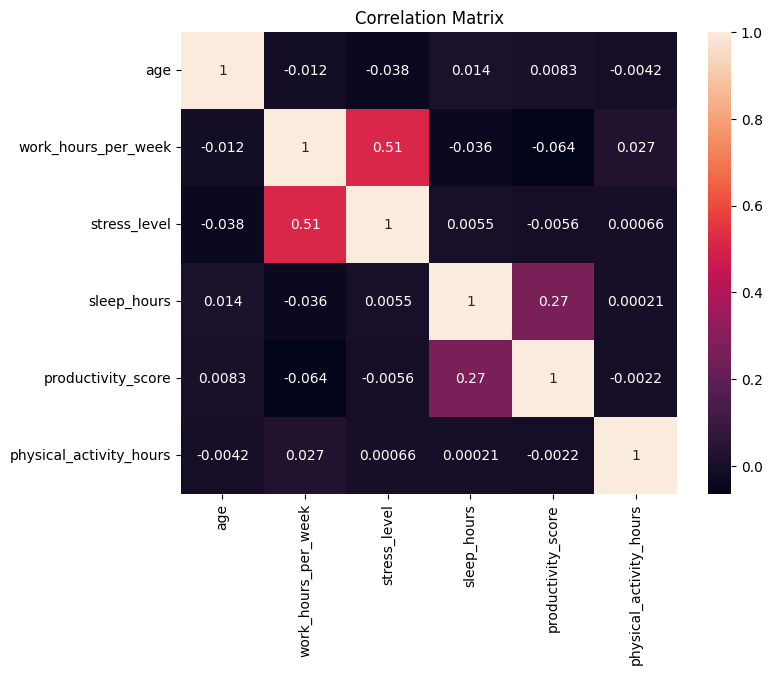

In [46]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

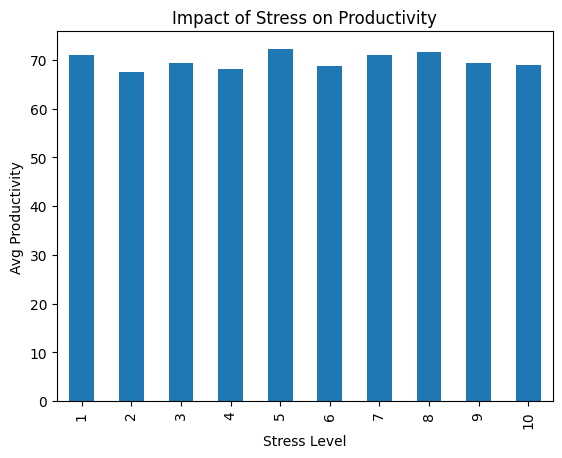

In [47]:
df.groupby('stress_level')['productivity_score'].mean().plot(kind='bar')
plt.title("Impact of Stress on Productivity")
plt.xlabel("Stress Level")
plt.ylabel("Avg Productivity")
plt.show()

/tmp/ipykernel_24807/4294260573.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sleep_category')['productivity_score'].mean().plot(kind='bar')


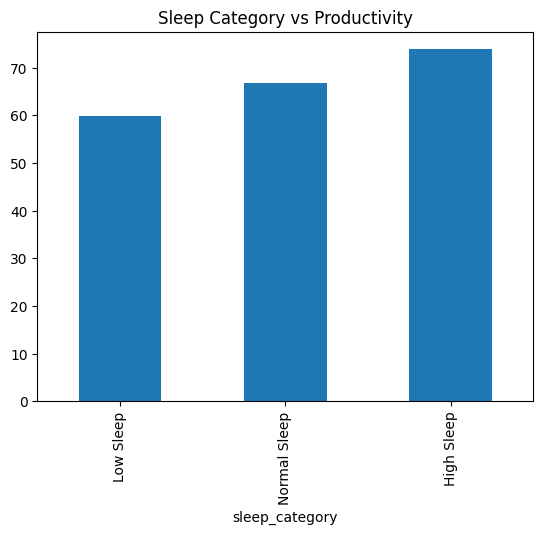

In [48]:
df['sleep_category'] = pd.cut(
    df['sleep_hours'],
    bins=[0, 5, 7, 10],
    labels=['Low Sleep', 'Normal Sleep', 'High Sleep']
)

df.groupby('sleep_category')['productivity_score'].mean().plot(kind='bar')
plt.title("Sleep Category vs Productivity")
plt.show()

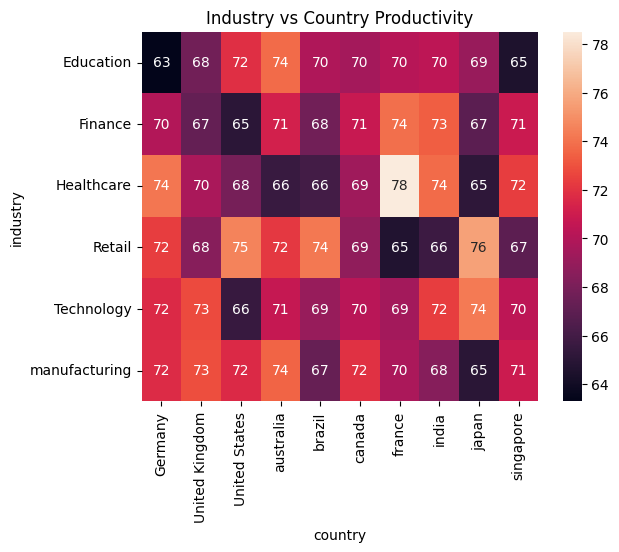

In [49]:
pivot = df.pivot_table(
    values='productivity_score',
    index='industry',
    columns='country',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True)
plt.title("Industry vs Country Productivity")
plt.show()

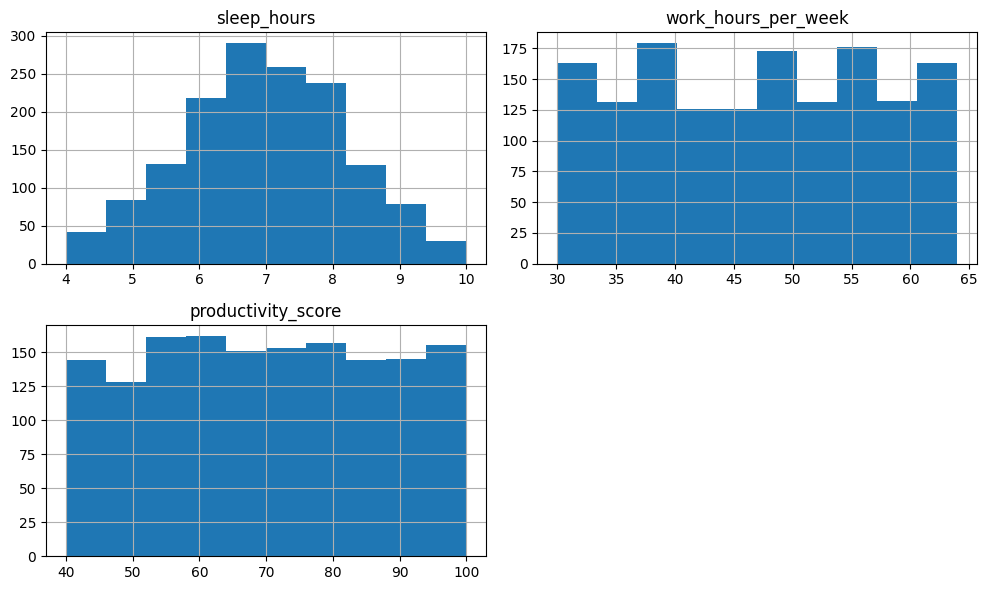

In [50]:
df[['sleep_hours','work_hours_per_week','productivity_score']].hist(figsize=(10,6))
plt.tight_layout()
plt.show()

In [51]:
from sklearn.linear_model import LinearRegression

X = df[['sleep_hours','work_hours_per_week']]
y = df['productivity_score']

model = LinearRegression()
model.fit(X, y)

print("Model Coefficients:", model.coef_)

Model Coefficients: [ 3.82104069 -0.09497672]


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("/content/sample_data/mental_health_productivity_2026.csv")

# Clean
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# Convert numeric
df['sleep_hours'] = pd.to_numeric(df['sleep_hours'], errors='coerce')
df['work_hours_per_week'] = pd.to_numeric(df['work_hours_per_week'], errors='coerce')
df['productivity_score'] = pd.to_numeric(df['productivity_score'], errors='coerce')

# Feature engineering
df['productivity_level'] = pd.cut(
    df['productivity_score'],
    bins=[0,40,70,100],
    labels=['Low','Medium','High']
)

df['sleep_category'] = pd.cut(
    df['sleep_hours'],
    bins=[0,5,7,10],
    labels=['Low','Normal','High']
)

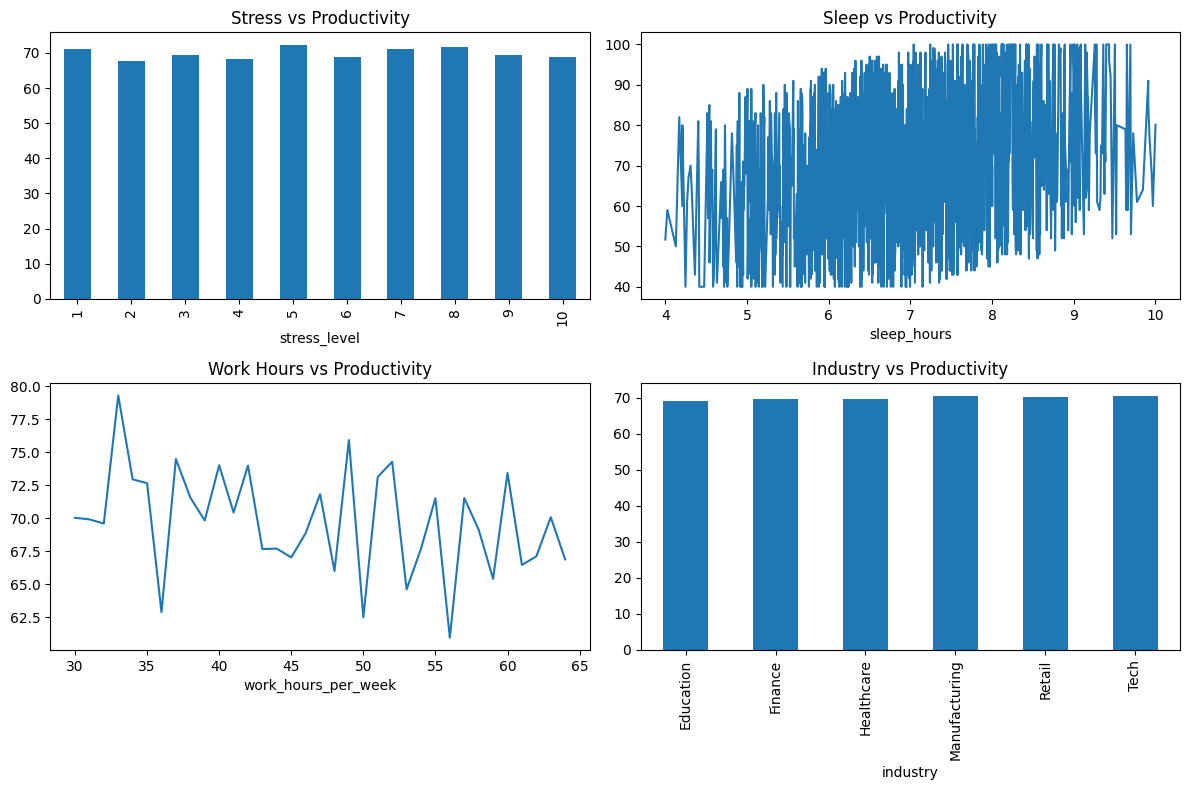

In [53]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

# Stress vs Productivity
df.groupby('stress_level')['productivity_score'].mean().plot(ax=axes[0,0], kind='bar')
axes[0,0].set_title("Stress vs Productivity")

# Sleep vs Productivity
df.groupby('sleep_hours')['productivity_score'].mean().plot(ax=axes[0,1])
axes[0,1].set_title("Sleep vs Productivity")

# Work vs Productivity
df.groupby('work_hours_per_week')['productivity_score'].mean().plot(ax=axes[1,0])
axes[1,0].set_title("Work Hours vs Productivity")

# Industry
df.groupby('industry')['productivity_score'].mean().plot(ax=axes[1,1], kind='bar')
axes[1,1].set_title("Industry vs Productivity")

plt.tight_layout()
plt.show()

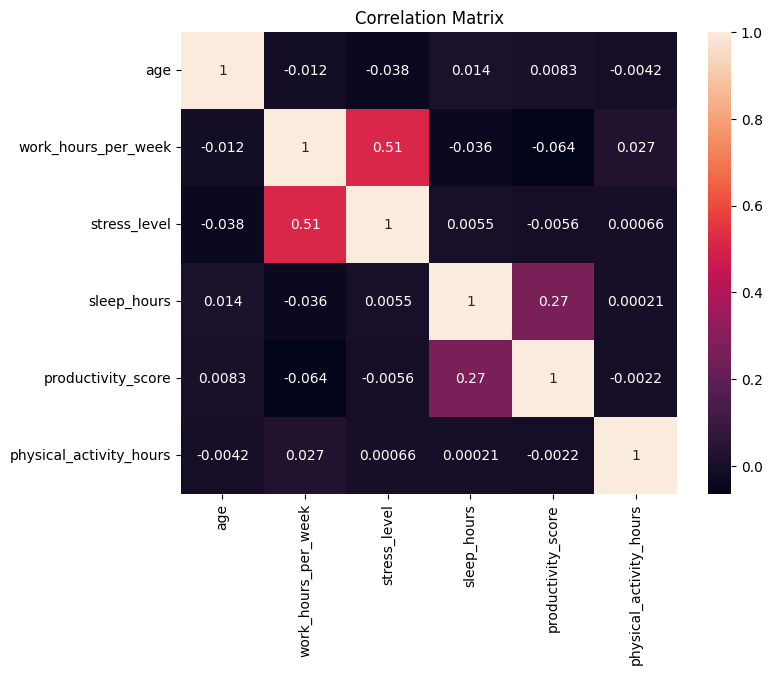

In [54]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

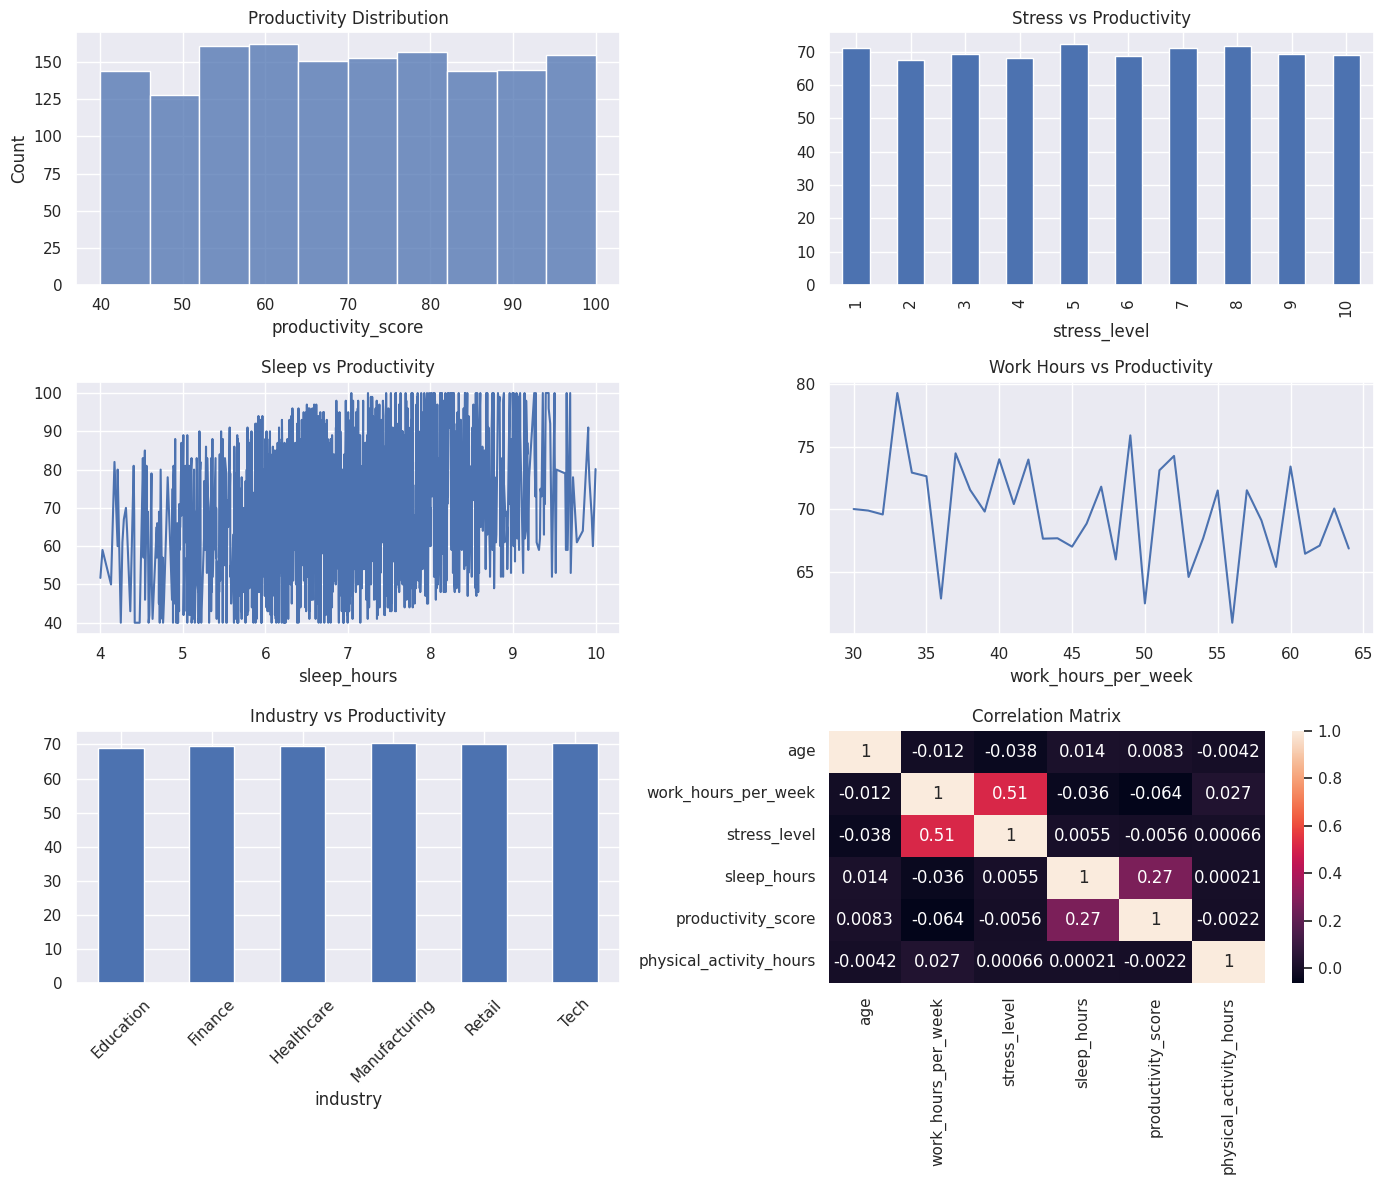

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# LOAD & CLEAN DATA
# ----------------------------
df = pd.read_csv("/content/sample_data/mental_health_productivity_2026.csv")

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns = df.columns.str.replace('\xa0', '', regex=True)

df.drop_duplicates(inplace=True)

# Convert numeric
df['sleep_hours'] = pd.to_numeric(df['sleep_hours'], errors='coerce')
df['work_hours_per_week'] = pd.to_numeric(df['work_hours_per_week'], errors='coerce')
df['productivity_score'] = pd.to_numeric(df['productivity_score'], errors='coerce')

# Fill missing
df.fillna(df.median(numeric_only=True), inplace=True)

# Feature engineering
df['productivity_level'] = pd.cut(
    df['productivity_score'],
    bins=[0,40,70,100],
    labels=['Low','Medium','High']
)

# ----------------------------
# CREATE MULTI-DASHBOARD
# ----------------------------
sns.set()

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# 1. Productivity Distribution
sns.histplot(df['productivity_score'], bins=10, ax=axes[0,0])
axes[0,0].set_title("Productivity Distribution")

# 2. Stress vs Productivity
df.groupby('stress_level')['productivity_score'].mean().plot(
    kind='bar', ax=axes[0,1]
)
axes[0,1].set_title("Stress vs Productivity")

# 3. Sleep vs Productivity
df.groupby('sleep_hours')['productivity_score'].mean().plot(
    ax=axes[1,0]
)
axes[1,0].set_title("Sleep vs Productivity")

# 4. Work Hours vs Productivity
df.groupby('work_hours_per_week')['productivity_score'].mean().plot(
    ax=axes[1,1]
)
axes[1,1].set_title("Work Hours vs Productivity")

# 5. Industry vs Productivity
df.groupby('industry')['productivity_score'].mean().plot(
    kind='bar', ax=axes[2,0]
)
axes[2,0].set_title("Industry vs Productivity")
axes[2,0].tick_params(axis='x', rotation=45)

# 6. Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, ax=axes[2,1])
axes[2,1].set_title("Correlation Matrix")

# Layout
plt.tight_layout()
plt.show()

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# LOAD & CLEAN DATA
# ----------------------------
df = pd.read_csv("/content/sample_data/mental_health_productivity_2026.csv")

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns = df.columns.str.replace('\xa0', '', regex=True)

df.drop_duplicates(inplace=True)

# Convert numeric
df['sleep_hours'] = pd.to_numeric(df['sleep_hours'], errors='coerce')
df['work_hours_per_week'] = pd.to_numeric(df['work_hours_per_week'], errors='coerce')
df['productivity_score'] = pd.to_numeric(df['productivity_score'], errors='coerce')

df.fillna(df.median(numeric_only=True), inplace=True)

# Feature engineering
df['productivity_level'] = pd.cut(
    df['productivity_score'],
    bins=[0,40,70,100],
    labels=['Low','Medium','High']
)

# ----------------------------
# STYLE
# ----------------------------
sns.set(style="whitegrid")

# ----------------------------
# DASHBOARD
# ----------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# 🎯 MAIN TITLE
fig.suptitle(
    "Mental Health & Productivity Dashboard (2026)",
    fontsize=20,
    fontweight='bold'
)

# 1. Productivity Distribution
sns.histplot(df['productivity_score'], bins=10, kde=True, ax=axes[0,0])
axes[0,0].set_title("Productivity Distribution")

# 2. Stress vs Productivity
df.groupby('stress_level')['productivity_score'].mean().plot(
    kind='bar', ax=axes[0,1]
)
axes[0,1].set_title("Stress vs Productivity")

# 3. Sleep vs Productivity
df.groupby('sleep_hours')['productivity_score'].mean().plot(
    ax=axes[1,0]
)
axes[1,0].set_title(" Sleep vs Productivity")

# 4. Work Hours vs Productivity
df.groupby('work_hours_per_week')['productivity_score'].mean().plot(
    ax=axes[1,1]
)
axes[1,1].set_title("Work Hours vs Productivity")

# 5. Industry vs Productivity
df.groupby('industry')['productivity_score'].mean().plot(
    kind='bar', ax=axes[2,0]
)
axes[2,0].set_title("Industry vs Productivity")
axes[2,0].tick_params(axis='x', rotation=45)

# 6. Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[2,1])
axes[2,1].set_title(" Correlation Matrix")

# Layout adjustment
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

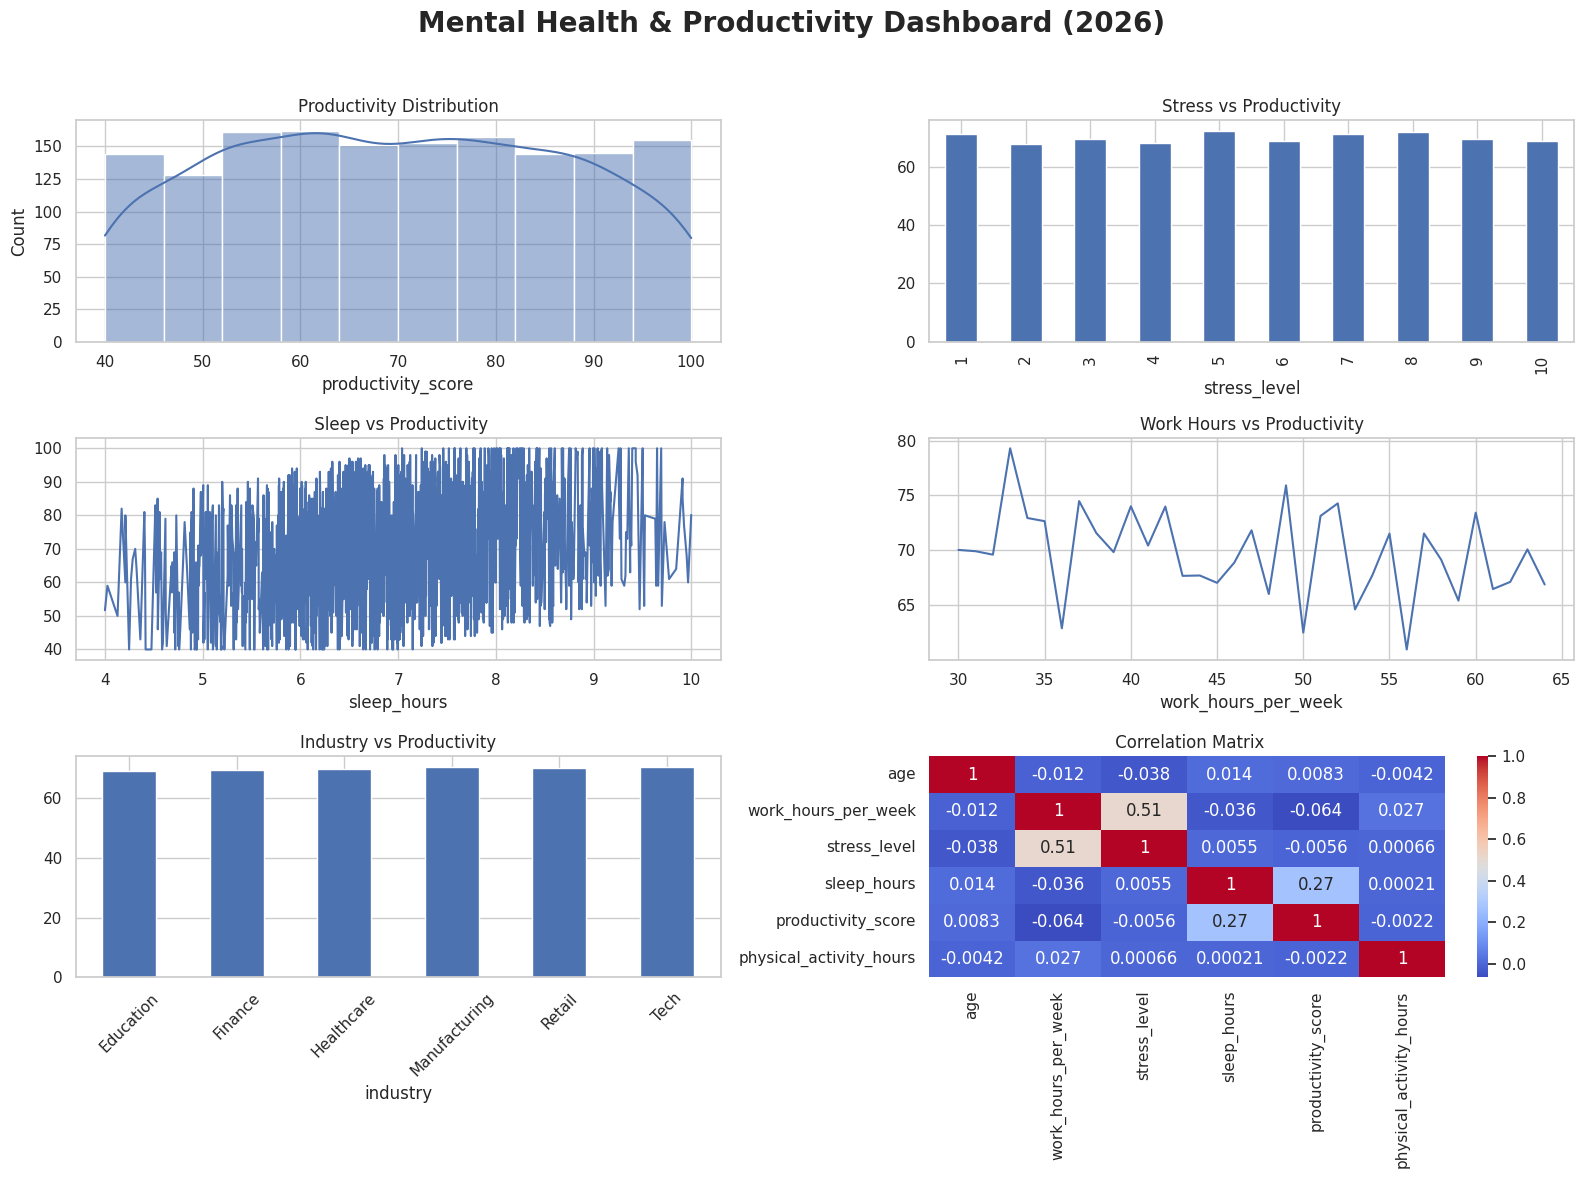

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# LOAD & CLEAN DATA
# ----------------------------
df = pd.read_csv("/content/sample_data/mental_health_productivity_2026.csv")

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns = df.columns.str.replace('\xa0', '', regex=True)

df.drop_duplicates(inplace=True)

# Convert numeric
df['sleep_hours'] = pd.to_numeric(df['sleep_hours'], errors='coerce')
df['work_hours_per_week'] = pd.to_numeric(df['work_hours_per_week'], errors='coerce')
df['productivity_score'] = pd.to_numeric(df['productivity_score'], errors='coerce')

df.fillna(df.median(numeric_only=True), inplace=True)

# Feature engineering
df['productivity_level'] = pd.cut(
    df['productivity_score'],
    bins=[0,40,70,100],
    labels=['Low','Medium','High']
)

# ----------------------------
# STYLE
# ----------------------------
sns.set(style="whitegrid")

# ----------------------------
# DASHBOARD
# ----------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# 🎯 MAIN TITLE
fig.suptitle(
    "Mental Health & Productivity Dashboard (2026)",
    fontsize=20,
    fontweight='bold'
)

# 1. Productivity Distribution
sns.histplot(df['productivity_score'], bins=10, kde=True, ax=axes[0,0])
axes[0,0].set_title("Productivity Distribution")

# 2. Stress vs Productivity
df.groupby('stress_level')['productivity_score'].mean().plot(
    kind='bar', ax=axes[0,1]
)
axes[0,1].set_title("Stress vs Productivity")

# 3. Sleep vs Productivity
df.groupby('sleep_hours')['productivity_score'].mean().plot(
    ax=axes[1,0]
)
axes[1,0].set_title(" Sleep vs Productivity")

# 4. Work Hours vs Productivity
df.groupby('work_hours_per_week')['productivity_score'].mean().plot(
    ax=axes[1,1]
)
axes[1,1].set_title("Work Hours vs Productivity")

# 5. Industry vs Productivity
df.groupby('industry')['productivity_score'].mean().plot(
    kind='bar', ax=axes[2,0]
)
axes[2,0].set_title("Industry vs Productivity")
axes[2,0].tick_params(axis='x', rotation=45)

# 6. Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[2,1])
axes[2,1].set_title(" Correlation Matrix")

# Layout adjustment
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

In [58]:
import pandas_gbq

# Make sure to install pandas-gbq if you haven't already:
# !pip install pandas-gbq

In [67]:
!pip install pandas-gbq


In [72]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_csv("/content/sample_data/mental_health_productivity_2026.csv")

# Clean
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns = df.columns.str.replace('\xa0', '', regex=True)
df.drop_duplicates(inplace=True)

# Convert numeric
df['sleep_hours'] = pd.to_numeric(df['sleep_hours'], errors='coerce')
df['work_hours_per_week'] = pd.to_numeric(df['work_hours_per_week'], errors='coerce')
df['productivity_score'] = pd.to_numeric(df['productivity_score'], errors='coerce')

df.fillna(df.median(numeric_only=True), inplace=True)

# ----------------------------
# INTERACTIVE CHARTS
# ----------------------------

# 1. Productivity Distribution
fig1 = px.histogram(df, x="productivity_score", title="Productivity Distribution")

# 2. Stress vs Productivity
fig2 = px.bar(
    df.groupby('stress_level')['productivity_score'].mean().reset_index(),
    x='stress_level', y='productivity_score',
    title="Stress vs Productivity"
)

# 3. Sleep vs Productivity
fig3 = px.scatter(
    df, x='sleep_hours', y='productivity_score',
    title="Sleep vs Productivity"
)

# 4. Work vs Productivity
fig4 = px.scatter(
    df, x='work_hours_per_week', y='productivity_score',
    title="Work Hours vs Productivity"
)

# 5. Industry Comparison
fig5 = px.bar(
    df.groupby('industry')['productivity_score'].mean().reset_index(),
    x='industry', y='productivity_score',
    title="Industry vs Productivity"
)

# Show all
fig1.show()
fig2.show()
fig3.show()
fig4.show()
fig5.show()

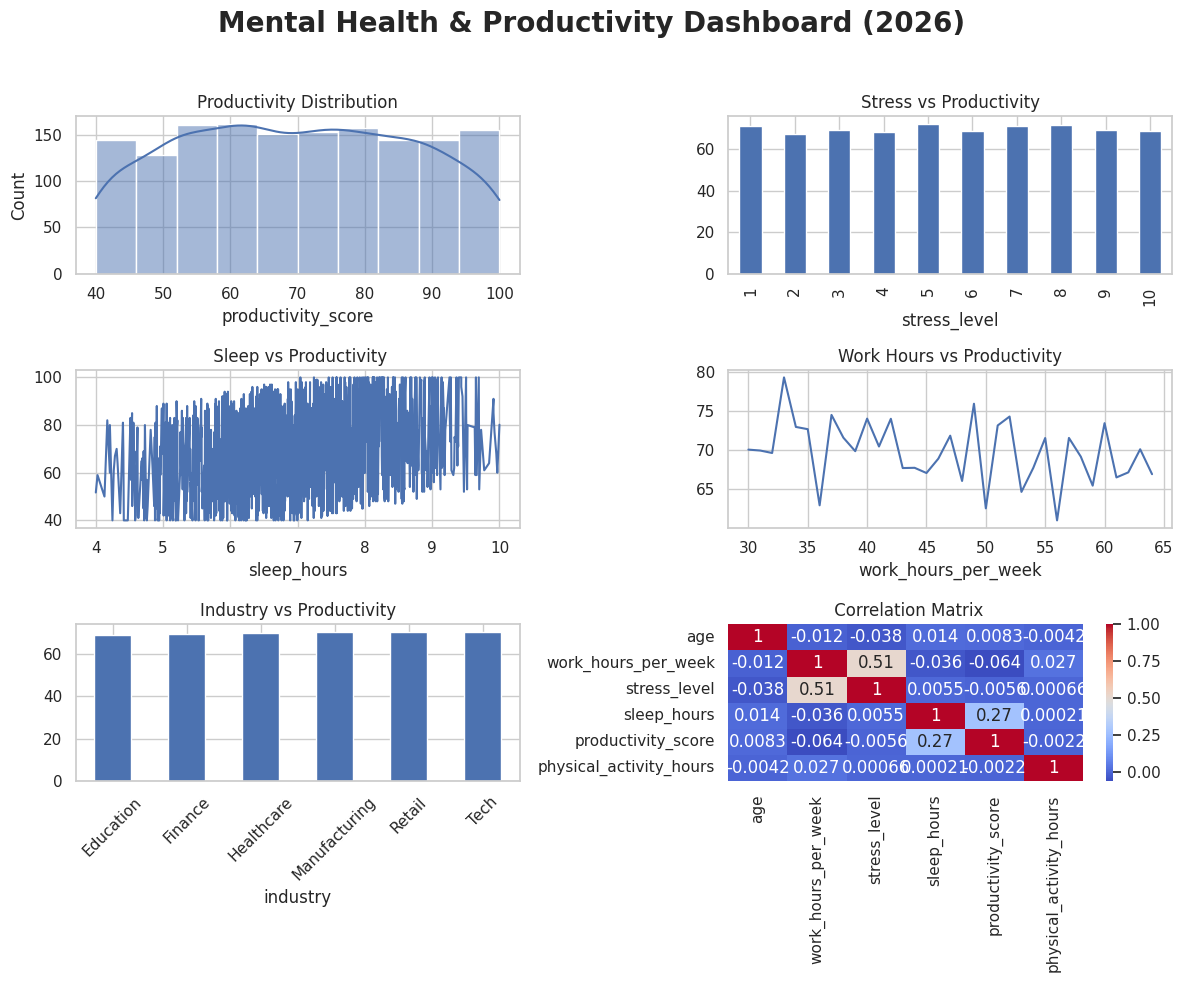

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# LOAD & CLEAN DATA
# ----------------------------
df = pd.read_csv("/content/sample_data/mental_health_productivity_2026.csv")

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns = df.columns.str.replace('\xa0', '', regex=True)

df.drop_duplicates(inplace=True)

# Convert numeric
df['sleep_hours'] = pd.to_numeric(df['sleep_hours'], errors='coerce')
df['work_hours_per_week'] = pd.to_numeric(df['work_hours_per_week'], errors='coerce')
df['productivity_score'] = pd.to_numeric(df['productivity_score'], errors='coerce')

df.fillna(df.median(numeric_only=True), inplace=True)

# Feature engineering
df['productivity_level'] = pd.cut(
    df['productivity_score'],
    bins=[0,40,70,100],
    labels=['Low','Medium','High']
)

# ----------------------------
# STYLE
# ----------------------------
sns.set(style="whitegrid")

# ----------------------------
# DASHBOARD
# ----------------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 10)) # Reduced figsize from (16, 12) to (12, 10)

# 🎯 MAIN TITLE
fig.suptitle(
    "Mental Health & Productivity Dashboard (2026)",
    fontsize=20,
    fontweight='bold'
)

# 1. Productivity Distribution
sns.histplot(df['productivity_score'], bins=10, kde=True, ax=axes[0,0])
axes[0,0].set_title("Productivity Distribution")

# 2. Stress vs Productivity
df.groupby('stress_level')['productivity_score'].mean().plot(
    kind='bar', ax=axes[0,1]
)
axes[0,1].set_title("Stress vs Productivity")

# 3. Sleep vs Productivity
df.groupby('sleep_hours')['productivity_score'].mean().plot(
    ax=axes[1,0]
)
axes[1,0].set_title(" Sleep vs Productivity")

# 4. Work Hours vs Productivity
df.groupby('work_hours_per_week')['productivity_score'].mean().plot(
    ax=axes[1,1]
)
axes[1,1].set_title("Work Hours vs Productivity")

# 5. Industry vs Productivity
df.groupby('industry')['productivity_score'].mean().plot(
    kind='bar', ax=axes[2,0]
)
axes[2,0].set_title("Industry vs Productivity")
axes[2,0].tick_params(axis='x', rotation=45)

# 6. Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[2,1])
axes[2,1].set_title(" Correlation Matrix")

# Layout adjustment
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()